# Perform resonant Confocals

## Scan

<span style="color:red; font-size:40px">
Remember to disable updates before starting the measurement!
</span>

Both in Attodry, as well as in Wavemeter-PC.

Turn on red laser (Amplifier) before starting. Also lock it, but this should be on.

Set resolution to 250px. Adjust window to 10x10um, look for exact coords in old scans (e.g. step 1)

In [1]:
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
import re
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import norm
import logging

In [2]:
# check if all relevant modules are loaded.

scanner_gui ##
scanning_data_logic
poi_manager_logic ##
scanning_optimize_logic
ibeam_smart ##
ws_wavemeter ##
scanning_probe_logic
dl_pro ##
powermeter ##
motordriver_pi3_remote ##

<qudi.hardware.motor.motordriver_pi3.Motordriver(0x1f24c7369f0) at 0x000001F250160380>

In [3]:
class perform_resonant_confocals():
    def __init__(self):
        return
    ##########################################################
    # confocal stuff
    def save_scan(self, name):
        print('saving 2d scan')
        scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
        scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
        dir_ = scanning_data_logic.module_default_data_dir
        return name, dir_

    def move_in_xy(self, xy_posi):
        x = xy_posi[0]
        y = xy_posi[1]
        z = poi_manager_logic.scanner_position[2]
        # poi_manager_logic.move_scanner([x,y,z]) # old approach
        scanning_probe_logic.set_target_position({'x':x, 'y':y, 'z':z}) # new approach
        return

    def do_optimize_and_wait(self):
        scanning_optimize_logic.start_optimize()
        while scanning_optimize_logic.module_state() == 'locked':
            time.sleep(1)
        optimal_position = scanning_optimize_logic.optimal_position
        return optimal_position
    
    def fix_optimizer(self):
        # Vlad magic to fix optimizer
        scanning_optimize_logic._delay_next_sequence_step = 15
        scanning_optimize_logic._optimize_spline_options = {
                "to_spline_2d": True,
                "s_2d": 1,
                "to_spline_1d": True,
                "s_1d": 1,
            }
        return
    
    ##########################################################
    # resonant laser stuff
    def set_laser_offset(self, v):
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            dlc._laser1.dl.pc.voltage_set.set(v)

    def get_set_laser_voltage(self):
        """Return the set voltage of the laser.
        Current voltage can differ.
        """
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            voltage = dlc._laser1.dl.pc.voltage_set.get()
        return voltage

    def get_actual_laser_voltage(self):
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            voltage = dlc._laser1.dl.pc.voltage_act.get()
        return voltage

    def get_voltage_range(self):
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            v_min = dlc._laser1.dl.pc.voltage_min.get()
            v_max = dlc._laser1.dl.pc.voltage_max.get()
        return v_min, v_max
    
    def go_slowly_to_detuning(self, target_detuning, epsilon=0.5, step_size=1):
        """ Changes laser votlage until detuning is close (roughly within epsilon) to desired value.

        Repeats tuning multiple times to minimize effect of mode hops:
        If a mode hop happened during the last step of the first detuning, it has more chances to reach the target value.
        If no mode hop happened, the function won't change the laser power and provoke no mode hops.

        Returns detuning if desired value was reached,
        returns None if value could not be reached

        epsilon in GHz
        step size in V.

        """

        for i in range(3):
            actual_detuning = self._go_slowly_to_detuning(target_detuning=target_detuning, epsilon=epsilon, step_size=step_size)
        return actual_detuning


    def _go_slowly_to_detuning(self, target_detuning, epsilon=0.5, step_size=1):
        """ Changes laser votlage until detuning is close (roughly within epsilon) to desired value.

        Returns detuning if desired value was reached,
        returns None if value could not be reached

        epsilon in GHz
        step size in V
        """
        actual_voltage = self.get_actual_laser_voltage()
        set_voltage = self.get_set_laser_voltage()
        offset = actual_voltage-set_voltage
        # v_min, v_max = get_voltage_range()
        v_min, v_max = 5, 135 # laser says -1,140 but better safe than sorry
        actual_detuning = self.get_detuning()
        
        if target_detuning > actual_detuning: # increase detuning
            step_size = abs(step_size)
            while actual_detuning < target_detuning - epsilon:
                set_voltage = set_voltage + step_size
                # print('increasing voltage to %.2f'%set_voltage)
                future_actual_voltage = set_voltage + offset
                if (not v_min <= future_actual_voltage <= v_max) or (set_voltage < v_min):
                    # voltage outside of allowed ones
                    print('Desired voltage outside range. Could not reach desired detuning of %.2fGHz, only %.2fGHz.'%(target_detuning, actual_detuning))
                    return None
                self.set_laser_offset(set_voltage)
                time.sleep(2)
                actual_detuning = self.get_detuning()
        else: # decrease detuning
            step_size = -abs(step_size)
            while actual_detuning > target_detuning + epsilon:
                set_voltage = set_voltage + step_size
                # print('decreasing voltage to %.2f'%set_voltage)
                future_actual_voltage = set_voltage + offset
                if (not v_min <= future_actual_voltage <= v_max) or (set_voltage < v_min):
                    # voltage outside of allowed ones
                    print('Desired voltage outside range. Could not reach desired detuning of %.2fGHz, only %.2fGHz.'%(target_detuning, actual_detuning))
                    return None
                self.set_laser_offset(set_voltage)
                time.sleep(2)
                actual_detuning = self.get_detuning()
        return actual_detuning

    ##########################################################
    # misc
    def turn_on_green(self, power = 100e3):
        # 80e3 are 80mW
        ibeam_smart.setPower(power)
        return

    def turn_off_green(self):
        ibeam_smart.setPower(0)
        return

    def _start_power_channel(self):
        powermeter.set_activity_state('Power', True)
        return

    def _stop_power_channel(self):
        powermeter.set_activity_state('Power', False)
        return

    def get_power(self):
        # in W
        self._start_power_channel()
        power = powermeter.get_process_value('Power')
        power = power*1e6 # convert to uW
        self._stop_power_channel()
        return power

    def get_detuning(self, w0=484.13):
        """w0 in THz"""
        print('asking wavemeter for wavelength')
        current_wl = ws_wavemeter.get_current_wavelength()
        bool_bad_wl = (np.isclose(current_wl, 0, atol=10)) or np.isnan(current_wl)
        _reps = 0
        max_reps = 10
        while bool_bad_wl and (_reps <= max_reps):
            print('Could not get detuning, repeating in 10s')
            time.sleep(10)
            current_wl = ws_wavemeter.get_current_wavelength()
            bool_bad_wl = (np.isclose(current_wl, 0, atol=10)) or np.isnan(current_wl)
            _reps += 1
        if _reps >= max_reps:
            print('Was not able to get a wavlength reading after %d tries'%_reps)
            return None
        wavelength = (current_wl - w0) * 1e3   # to GHz
        print('got wavelength')
        return wavelength

    def gaussian_1d(self, x,a,x0,sigma):
        return a*np.exp(-(x-x0)**2/(2*sigma**2))


    def plot_measurements_on_gaussian(self, x0, sigma, x):
        xx = np.linspace(-4*sigma+x0,4*sigma+x0, 100)
        yy = self.gaussian_1d(xx,1,x0, sigma)
        y = self.gaussian_1d(x,1,x0, sigma)
        plt.plot(xx,yy, label = 'gaussian\nx0=%d, sigma=%d'%(x0,sigma))
        plt.plot(x,y,'x', label='proposed points')
        plt.xlabel('detuning [GHz]')
        plt.legend()


    def calc_best_points_for_gauss(self, x0, sigma, N, do_plot=False):
        # N should be odd so dtapoint at predicted max.
        # most points near the top, less in the tails
        p = np.linspace(0.001,0.999,N) # starting at -3sigma, ending at 3 sigma
        x = norm.ppf(p, loc=x0, scale=sigma)
        if do_plot:
            self.plot_measurements_on_gaussian(x0=x0, sigma=sigma, x=x)
        return x
    

    ###################################################################
    # change laserpower

    def rotate_filterwheel(self, pos, limits=(0,360)):
        min_pos = limits[0]
        max_pos = limits[1]
        pos = min_pos if pos <= min_pos else pos
        pos = max_pos if pos >= max_pos else pos
        motordriver_pi3_remote.current_motor = 1
        motordriver_pi3_remote.motor_position = pos
        time.sleep(0.5)
        return pos
    
    def adjust_power(self, target_power, step_size=1, epsilon=0.5, limits_filterwheel=(0,360)):
        # self.start_power_channel()
        actual_power = self.get_power()
        actual_posi = motordriver_pi3_remote.motor_position
        target_posi = actual_posi
        if actual_power >= target_power+epsilon:
            # power too big, need to decrease power, need to increase angle
            print('decreasing power')
            step = abs(step_size)
            while actual_power >= target_power+epsilon:
                target_posi = target_posi +  step
                print('moving to posi %.1f°'%target_posi)
                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                actual_power = self.get_power()
                if actual_posi >= limits_filterwheel[1]-step_size:
                    print('Reached lower limit of filterwheel position, power is %fuW'%actual_power)
                    # self.stop_power_channel()
                    return actual_power
            print('reached target: %fuW.'%actual_power)
            # self.stop_power_channel()
            return actual_power
        elif actual_power <= target_power-epsilon:
            # power too small, need to increase power, need to decrease angle
            print('increasing power')
            step = -abs(step_size)
            while actual_power <= target_power-epsilon:
                target_posi = target_posi +  step
                print('moving to posi %.1f°'%target_posi)
                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                actual_power = self.get_power()
                if actual_posi <= limits_filterwheel[0]+step_size:
                    print('Reached upper limit of filterwheel position, power is %fuW'%actual_power)
                    # self.stop_power_channel()
                    return actual_power
            print('reached target: %fuW.'%actual_power)
            # self.stop_power_channel()
            return actual_power
        else:
            print('power was fine: %fuW'%actual_power)
            # self.stop_power_channel()
            return actual_power
        
measurement = perform_resonant_confocals()

### Check orientation powerwheel

In [4]:
posis = np.linspace(0, 360, 91)
powers = np.zeros(len(posis))
for i, posi in enumerate(posis):
    print(posi)
    a = measurement.rotate_filterwheel(posi, limits=[0,360])
    power = measurement.get_power()
    powers[i] = power

0.0
4.0
8.0
12.0
16.0
20.0
24.0
28.0
32.0
36.0
40.0
44.0
48.0
52.0
56.0
60.0
64.0
68.0
72.0
76.0
80.0
84.0
88.0
92.0
96.0
100.0
104.0
108.0
112.0
116.0
120.0
124.0
128.0
132.0
136.0
140.0
144.0
148.0
152.0
156.0
160.0
164.0
168.0
172.0
176.0
180.0
184.0
188.0
192.0
196.0
200.0
204.0
208.0
212.0
216.0
220.0
224.0
228.0
232.0
236.0
240.0
244.0
248.0
252.0
256.0
260.0
264.0
268.0
272.0
276.0
280.0
284.0
288.0
292.0
296.0
300.0
304.0
308.0
312.0
316.0
320.0
324.0
328.0
332.0
336.0
340.0
344.0
348.0
352.0
356.0
360.0


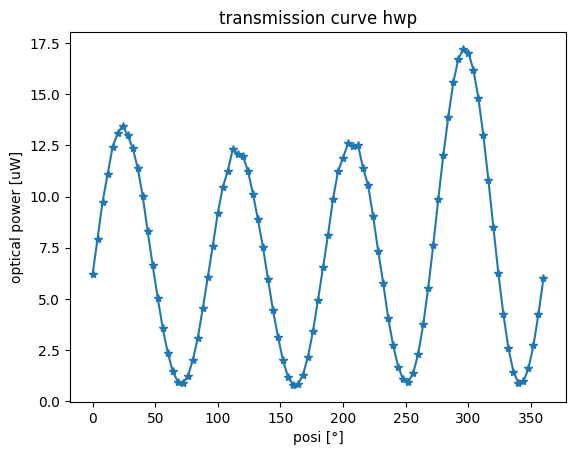

In [5]:
plt.plot(posis, powers, '*-')
plt.title('transmission curve hwp')
plt.xlabel('posi [°]')
plt.ylabel('optical power [uW]')
plt.show()

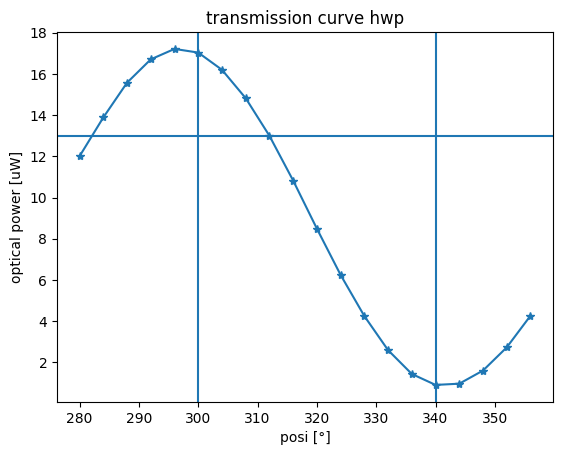

In [10]:
# look for falling slope
anf, end = 70,90
lims_wheel_manual = [300,340]
target_power_manual = 13

plt.plot(posis[anf:end], powers[anf:end], '*-')
plt.axvline(lims_wheel_manual[0])
plt.axvline(lims_wheel_manual[1])
plt.axhline(target_power_manual)
plt.title('transmission curve hwp')
plt.xlabel('posi [°]')
plt.ylabel('optical power [uW]')
plt.show()

In [11]:
measurement.rotate_filterwheel(310)

310

### Prepare measurement

In [12]:
measurement.get_detuning()

asking wavemeter for wavelength
got wavelength


0.7662223713964522

In [9]:
scanning_optimize_logic._delay_next_sequence_step = 1

In [13]:
measurement.fix_optimizer()

In [ ]:
path_to_data = os.path.abspath(r'Z:\Oliver\measurements\238\2025-02-04_resonant-confocals\region-D_step-2\try-10')

detunings = measurement.calc_best_points_for_gauss(x0=5, sigma=20, N=11)
detunings = np.array([0, -100, -80, -59, -40, -30, -20, -10, 0, 10, 20, 30, 40, 60, 80, 100], dtype=np.float64)
num_steps = len(detunings)
print(detunings)

[  0. -59. -40. -30. -20. -10.   0.  10.  20.  30.  40.  60.  80. 100.]


In [15]:
# Vlad magic to fix optimizer
measurement.fix_optimizer()

In [16]:
# optimize on good defect
# this one will be used for realignment
measurement.turn_on_green()
opt = measurement.do_optimize_and_wait()
print(opt)

{'x': -1.4334098143459184e-06, 'y': -5.166131464417178e-06, 'z': 5.278184684684684e-06}


In [17]:
scan_names = {}
experiment_name = "resonant-confocal"
# Loop through detunings
for i, detuning in enumerate(detunings):
    _detuning = measurement.go_slowly_to_detuning(detuning)
    if _detuning is None:
        actual_detuning = measurement.get_detuning()
        print('Did not reach target. Ended at %f'%actual_detuning)
        continue
    else:
        print('Reached %fGHz'%_detuning)
    wavelength = _detuning # keep consistency with legacy code

    # keep opticla power constant
    # target power and limits were set manually during checking the powerwheel
    measurement.adjust_power(target_power=target_power_manual, step_size=0.1, epsilon=0.5, limits_filterwheel=lims_wheel_manual)

    # turn on green
    measurement.turn_on_green()

    # go to good defect
    # do optimization once before, then always go to last opt posi
    print('moving scanner')
    # poi_manager_logic.move_scanner(opt)
    scanning_probe_logic.set_target_position(opt)

    # optimize on defect
    print('optimizing')
    for j in range(4):
        opt = measurement.do_optimize_and_wait()
        print(opt)

    # turn off green
    measurement.turn_off_green()
    time.sleep(3)

    # get start time in seconds
    time_start = time.time()
    optical_powers = []

    # Start scan and save data
    print('starting scan')
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time_now =  time.time()
            elapsed = time_now - time_start
            power = measurement.get_power()
            optical_powers.append((elapsed, power))
            time.sleep(10)
    
    name, dir_ = measurement.save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})
    timestamp = datetime.now().strftime("%Y%m%d-%H%M-%S")
    savename = r'%s\%s_optical-power_%s.txt'%(path_to_data, datetime.now().strftime("%Y%m%d-%H%M-%S"), name)
    np.savetxt(savename, optical_powers, delimiter="\t", fmt="%f", header='time[s]\tpower[uW]')

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
Could not get detuning, repeating in 10s
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
Reached 0.363119GHz
decreasing power
moving to posi 310.1°
moving to posi 310.2°
moving to posi 310.3°
moving to posi 310.4°
moving to posi 310.5°
moving to posi 310.6°
reached target: 13.496716uW.
moving scanner
optimizing
{'x': -1.4225663003372685e-06, 'y': -5.1777828680274124e-06, 'z': 5.306827927927928e-06}
{'x': -1.421960187092535e-06, 'y': -5.182335596959855e-06, 'z': 5.246439639639639e-06}
{'x': -1.4197789550482628e-06, 'y': -5.1812635788582854e-06, 'z': 5.254508108108108e-06}
{'x': -1.4191450293368894e-06, 'y': -5.179153427720204e-06, 'z': 5.168914414414415e-06}
starting scan
saving 2d scan
Scan 1/14 completed for 0.36 GHz
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
Could not get detuning, repeating in 10s
got waveleng

TimeoutError: result expired

# Other stuff

## automatic measurement

In [ ]:
ibeam_smart.getPower()

In [ ]:
# position as array or dict
position = {'x': 0, 'y': 0, 'z': 0}
poi_manager_logic.move_scanner(position)

## Get confocal image

In [15]:
import matplotlib.pyplot as plt
import numpy as np

In [31]:
scan_data = scanning_data_logic.get_current_scan_data()

In [32]:
source = 'APD1'

data = scan_data.data[source]
(xrange,yrange) = scan_data.scan_range

In [ ]:
imgdata = np.fliplr(np.array(data)).transpose() # scudi displayes in a weird way.
extent=[xrange[0],xrange[1],yrange[0],yrange[1]]
plt.imshow(imgdata, extent=extent, cmap='RdBu_r')

## Vlads code to change resonant laser freq

In [ ]:
ple_gui

In [8]:
motordriver_pi3_remote.current_motor = 1

motordriver_pi3_remote.current_motor = 1
motordriver_pi3_remote.motor_position = 75

bad positions
55 to 75
135 to 150
300 to 335

In [52]:
motordriver_pi3_remote.motor_position = 75

In [ ]:
scanner_gui

In [ ]:
ws_wavemeter

In [ ]:
scanning_probe_logic

In [ ]:
wavelengthset_laser_offset

In [2]:

# %%
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

def save_scan(name):
    scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
    scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
    dir_ = scanning_data_logic.module_default_data_dir
    return name, dir_

#to be rapaired:
def set_laser_offset(v):
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc._laser1.dl.pc.voltage_set.set(v)


In [ ]:
plot_data_from_dict(data_signal0)

In [ ]:
motordriver_pi3.current_motor = 0

In [ ]:
ws_wavemeter.start_acquisition()
# %%
# Parameters
start_freq = 0  # GHz to Hz
end_freq = 18500  # GHz to Hz
step = 5000 #100  # GHz to Hz
num_steps = int((end_freq - start_freq) / step) + 1  # +1 for inclusive range
#resolution = (150, 150)  # x, y points

w0 = 484.130 #THz
# Data structure for results
frequencies = np.linspace(start_freq, end_freq, num_steps)

scan_names = {}
experiment_name = "resonant-confocal"
# Loop through frequencies
for i, freq in enumerate(frequencies):
    # Set laser frequency
    go_to_ple_target(freq)
    time.sleep(3)

    # Measure and record wavelength
    wavelength = (ws_wavemeter.get_current_wavelength() - w0) * 1e3   # to GHz
    print(wavelength)

    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

# %%
ws_wavemeter.start_acquisition()
(ws_wavemeter.get_current_wavelength() - 484.130) * 1e3

# %%

# Process data (replace with your specific code)
# Here's an example using NumPy:
fluorescence_intensities = []
for data, _ in scan_data:
    # Assuming data is a 2D array of fluorescence intensities
    fluorescence_intensities.append(data.sum(axis=0))  # Sum along y-axis

# Create histograms (adapt binning as needed)
for i, intensity in enumerate(fluorescence_intensities):
    plt.hist(intensity, bins=50, label=f"{frequencies[i] / 1e9:.2f} GHz")

plt.xlabel("Fluorescence Intensity")
plt.ylabel("Count")
plt.title("Fluorescence Intensity at Different Frequencies")
plt.legend()
plt.show()


# Check offset between resonant and off resonant

In [8]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

def turn_on_green(power = 80e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

In [ ]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

# settings optimizer logic
settings = {
    'scan_frequency' : {'z': 5.0, 'x': 100.0, 'y': 100.0},
    'data_channel' : 'APD1',
    'scan_range' : {'z': 1.8e-06, 'x': 4e-07, 'y': 4e-07},
    'scan_resolution': {'z': 200, 'x': 25, 'y': 25},
    'scan_sequence': [('x', 'y'), 'z']
}
scanning_optimize_logic.set_optimize_settings(settings)

In [ ]:
coords_green = np.zeros(3)
coords_red = np.zeros(3)
for i in range(10):
    turn_on_green()
    _opt = do_optimize_and_wait()
    opt = np.array([float(_opt['x']),float(_opt['y']),float(_opt['z'])])
    coords_green = np.vstack((coords_green,opt))
    print('green')
    print(coords_green)
    turn_off_green()
    _opt = do_optimize_and_wait()
    opt = np.array([float(_opt['x']),float(_opt['y']),float(_opt['z'])])
    coords_red = np.vstack((coords_red,opt))
    print('red')
    print(coords_red)

In [ ]:
# coords_green = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
# [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
# [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]
# [-1.11442618e-08 -5.40684737e-06  1.82952883e-06]
# [-2.05469319e-08 -5.38524593e-06  2.03309189e-06]
# [-1.90723863e-08 -5.38167088e-06  1.98445135e-06]
# [-2.19087487e-08 -5.37961598e-06  1.99794144e-06]
# [-7.76273520e-09 -5.36210570e-06  2.07177387e-06]
# [-1.69062759e-08 -5.37110687e-06  2.09605135e-06]
# [-3.51968970e-08 -5.33262472e-06  2.24019550e-06]
# [-3.19011560e-08 -5.33016759e-06  2.27804234e-06]]

# coords_red = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
# [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
# [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]
# [-2.62242350e-09 -5.40146280e-06  2.04124054e-06]
# [-2.39039374e-08 -5.38198267e-06  2.05201892e-06]
# [-1.37417728e-08 -5.38511219e-06  2.05747297e-06]
# [-4.45747457e-09 -5.36457887e-06  2.07627838e-06]
# [-1.58719099e-08 -5.36153447e-06  2.14474685e-06]
# [-1.76755453e-08 -5.34930733e-06  2.25370901e-06]
# [-3.56750859e-08 -5.33683790e-06  2.23569550e-06]
# [-4.18681824e-08 -5.32877437e-06  2.17263694e-06]]

In [ ]:
plt.plot(coords_green[1:,2],label='green', color='g')
plt.plot(coords_red[1:,2],label='red', color='r')
plt.legend()
plt.title('z positions from optimize')
plt.show()
plt.plot(coords_red[1:,2] - coords_green[1:,2])
plt.title('z red - z green, avg = %f um'%(1e6*np.mean(coords_red[1:,2] - coords_green[1:,2])))

# Check power dependence on detuning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro, NetworkConnection
import time

In [41]:
class testing_powerdepednence():
        def __init__(self):
                return
        
        def set_laser_offset(self, v):
                with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
                        dlc._laser1.dl.pc.voltage_set.set(v)
                return

        def _start_power_channel(self):
                powermeter.set_activity_state('Power', True)
                return

        def _stop_power_channel(self):
                powermeter.set_activity_state('Power', False)
                return

        def get_power(self):
                # in W
                self._start_power_channel()
                power = powermeter.get_process_value('Power')
                power = power*1e6 # convert to uW
                self._stop_power_channel()
                return power

        def rotate_filterwheel(self, pos, limits=(0,360)):
                min_pos = limits[0]
                max_pos = limits[1]
                pos = min_pos if pos <= min_pos else pos
                pos = max_pos if pos >= max_pos else pos
                motordriver_pi3_remote.current_motor = 1
                motordriver_pi3_remote.motor_position = pos
                time.sleep(0.5)
                return pos
        
        def adjust_power(self, target_power, step_size=1, epsilon=0.5, limits_filterwheel=(58,102)):
                # self.start_power_channel()
                actual_power = self.get_power()
                actual_posi = motordriver_pi3_remote.motor_position
                target_posi = actual_posi
                if actual_power >= target_power+epsilon:
                        # power too big, need to decrease power, need to increase angle
                        print('decreasing power')
                        step = abs(step_size)
                        while actual_power >= target_power+epsilon:
                                target_posi = target_posi +  step
                                print('moving to posi %.1f°'%target_posi)
                                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                                actual_power = self.get_power()
                                if actual_posi >= limits_filterwheel[1]-step_size:
                                        print('Reached lower limit of filterwheel position, power is %fuW'%actual_power)
                                        # self.stop_power_channel()
                                        return actual_power
                        print('reached target: %fuW.'%actual_power)
                        # self.stop_power_channel()
                        return actual_power
                elif actual_power <= target_power-epsilon:
                        # power too small, need to increase power, need to decrease angle
                        print('increasing power')
                        step = -abs(step_size)
                        while actual_power <= target_power-epsilon:
                                target_posi = target_posi +  step
                                print('moving to posi %.1f°'%target_posi)
                                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                                actual_power = self.get_power()
                                if actual_posi <= limits_filterwheel[0]+step_size:
                                        print('Reached upper limit of filterwheel position, power is %fuW'%actual_power)
                                        # self.stop_power_channel()
                                        return actual_power
                        print('reached target: %fuW.'%actual_power)
                        # self.stop_power_channel()
                        return actual_power
                else:
                        print('power was fine: %fuW'%actual_power)
                        # self.stop_power_channel()
                        return actual_power
        
        def get_detuning(self, w0=484.13):
                """w0 in THz"""
                print('asking wavemeter for wavelength')
                current_wl = ws_wavemeter.get_current_wavelength()
                if np.isclose(current_wl,0,atol=10):
                        print('Could not get detuning, repeating in 10s')
                        time.sleep(10)
                        current_wl = ws_wavemeter.get_current_wavelength()
                wavelength = (current_wl - w0) * 1e3   # to GHz
                print('got wavelength')
                return wavelength
        
tester = testing_powerdepednence()

In [22]:
limits_filterwheel = [50,110]
posis = np.linspace(limits_filterwheel[0], limits_filterwheel[1], 50)
powers = np.zeros(len(posis))
for i, posi in enumerate(posis):
    a = tester.rotate_filterwheel(posi, limits=[0,360])
    time.sleep(0.1)
    # tester.start_power_channel()
    power = tester.get_power()
    # tester.stop_power_channel()
    powers[i] = power

In [ ]:
plt.plot(posis, powers, '*-')
plt.axvline(58)
plt.axvline(102)
plt.title('transmission curve hwp')
plt.xlabel('posi [°]')
plt.ylabel('optical power [uW]')
plt.show()

In [ ]:
tester.rotate_filterwheel(70, limits=[0,360])
print(tester.get_power())

In [ ]:
n_points = 10
voltages = np.linspace(5, 135, n_points)
target_power = 200
print(voltages)

powers = np.zeros(n_points)
powers_adjusted = np.zeros(n_points)
detunings = np.zeros(n_points)


for i, voltage in enumerate(voltages):
    tester.set_laser_offset(voltage)
    time.sleep(2)
    detuning = 0# tester.get_detuning()
    power = tester.get_power()
    detunings[i] = detuning
    powers[i] = power

In [ ]:
plt.plot(voltages, powers)
plt.xlabel('laser set voltage [V]')
plt.ylabel('optical power [uW]')
plt.show()

In [ ]:
n_points = 10
voltages = np.linspace(5, 135, n_points)
target_power = 200
print(voltages)

powers = np.zeros(n_points)
powers_adjusted = np.zeros(n_points)
detunings = np.zeros(n_points)


for i, voltage in enumerate(voltages):
    tester.set_laser_offset(voltage)
    time.sleep(2)
    detuning = 0# tester.get_detuning()
    power_adjusted = tester.adjust_power(target_power, step_size = 0.1, epsilon=0.5, limits_filterwheel=[58,102])
    #tester.start_power_channel()
    power = tester.get_power()
    #tester.stop_power_channel()
    detunings[i] = detuning
    powers[i] = power
    powers_adjusted[i] = power_adjusted


In [ ]:
#plt.plot(detunings, powers)
#plt.plot(detunings, powers_adjusted)
#plt.xlabel('detuning [GHz]')
#plt.ylabel('optical power [uW]')
#plt.show()

plt.plot(voltages, powers)
plt.plot(voltages, powers_adjusted)
plt.xlabel('laser set voltage [V]')
plt.ylabel('optical power [uW]')
plt.show()

In [ ]:
tester.adjust_power(300, step_size=1, epsilon=0.5, limits_filterwheel=[58,102])

## random

In [ ]:
scanning_probe_logic
ibeam_smart

In [4]:
def turn_on_green(power = 80e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

In [5]:
turn_on_green()

In [ ]:
# bleaching

do_opt = True

def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

import time

if do_opt:
    opt = do_optimize_and_wait()

for i in range(999):
    print(i)

    if do_opt:
        poi_manager_logic.move_scanner(opt)
        opt = do_optimize_and_wait()
    
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    

# Perform confocals (old)

## Scan

<span style="color:red; font-size:40px">
Remember to disable updates before starting the measurement!
</span>

Both in Attodry, as well as in Wavemeter-PC.

Turn on red laser (Amplifier) before starting. Also lock it, but this should be on.

Set resolution to 250px. Adjust window to 10x10um, look for exact coords in old scans (e.g. step 1)

In [1]:
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
import re
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import norm
import logging

In [ ]:
scanner_gui ##
scanning_data_logic
poi_manager_logic ##
scanning_optimize_logic
ibeam_smart ##
ws_wavemeter ##
scanning_probe_logic
dl_pro ##
powermeter ##
motordriver_pi3_remote ##

In [48]:
class perform_resonant_confocals():
    def __init__(self):
        return
    ##########################################################
    # confocal stuff
    def save_scan(self, name):
        print('saving 2d scan')
        scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
        scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
        dir_ = scanning_data_logic.module_default_data_dir
        return name, dir_

    def move_in_xy(self, xy_posi):
        x = xy_posi[0]
        y = xy_posi[1]
        z = poi_manager_logic.scanner_position[2]
        poi_manager_logic.move_scanner([x,y,z])
        return

    def do_optimize_and_wait(self):
        scanning_optimize_logic.start_optimize()
        while scanning_optimize_logic.module_state() == 'locked':
            time.sleep(1)
        optimal_position = scanning_optimize_logic.optimal_position
        return optimal_position
    
    ##########################################################
    # resonant laser stuff
    def set_laser_offset(self, v):
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            dlc._laser1.dl.pc.voltage_set.set(v)

    def get_set_laser_voltage(self):
        """Return the set voltage of the laser.
        Current voltage can differ.
        """
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            voltage = dlc._laser1.dl.pc.voltage_set.get()
        return voltage

    def get_actual_laser_voltage(self):
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            voltage = dlc._laser1.dl.pc.voltage_act.get()
        return voltage

    def get_voltage_range(self):
        with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
            v_min = dlc._laser1.dl.pc.voltage_min.get()
            v_max = dlc._laser1.dl.pc.voltage_max.get()
        return v_min, v_max
    
    def go_slowly_to_detuning(self, target_detuning, epsilon=0.5, step_size=1):
        """ Changes laser votlage until detuning is close (roughly within epsilon) to desired value.

        Repeats tuning multiple times to minimize effect of mode hops:
        If a mode hop happened during the last step of the first detuning, it has more chances to reach the target value.
        If no mode hop happened, the function won't change the laser power and provoke no mode hops.

        Returns detuning if desired value was reached,
        returns None if value could not be reached

        epsilon in GHz
        step size in V.

        """
        for i in range(3):
            actual_detuning = self.go_slowly_to_detuning(self, target_detuning=target_detuning, epsilon=epsilon, step_size=step_size)
        return actual_detuning


    def _go_slowly_to_detuning(self, target_detuning, epsilon=0.5, step_size=1):
        """ Changes laser votlage until detuning is close (roughly within epsilon) to desired value.

        Returns detuning if desired value was reached,
        returns None if value could not be reached

        epsilon in GHz
        step size in V
        """
        actual_voltage = self.get_actual_laser_voltage()
        set_voltage = self.get_set_laser_voltage()
        offset = actual_voltage-set_voltage
        # v_min, v_max = get_voltage_range()
        v_min, v_max = 5, 135 # laser says -1,140 but better safe than sorry
        time.sleep(2)
        actual_detuning = self.get_detuning()
        
        if target_detuning > actual_detuning: # increase detuning
            step_size = abs(step_size)
            while actual_detuning < target_detuning - epsilon:
                set_voltage = set_voltage + step_size
                # print('increasing voltage to %.2f'%set_voltage)
                future_actual_voltage = set_voltage + offset
                if (not v_min <= future_actual_voltage <= v_max) or (set_voltage < v_min):
                    # voltage outside of allowed ones
                    print('Desired voltage outside range. Could not reach desired detuning of %.2fGHz, only %.2fGHz.'%(target_detuning, actual_detuning))
                    return None
                self.set_laser_offset(set_voltage)
                time.sleep(2)
                actual_detuning = self.get_detuning()
        else: # decrease detuning
            step_size = -abs(step_size)
            while actual_detuning > target_detuning + epsilon:
                set_voltage = set_voltage + step_size
                # print('decreasing voltage to %.2f'%set_voltage)
                future_actual_voltage = set_voltage + offset
                if (not v_min <= future_actual_voltage <= v_max) or (set_voltage < v_min):
                    # voltage outside of allowed ones
                    print('Desired voltage outside range. Could not reach desired detuning of %.2fGHz, only %.2fGHz.'%(target_detuning, actual_detuning))
                    return None
                self.set_laser_offset(set_voltage)
                time.sleep(2)
                actual_detuning = self.get_detuning()
        return actual_detuning

    ##########################################################
    # misc
    def turn_on_green(self, power = 100e3):
        # 80e3 are 80mW
        ibeam_smart.setPower(power)
        return

    def turn_off_green(self):
        ibeam_smart.setPower(0)
        return

    def _start_power_channel(self):
        powermeter.set_activity_state('Power', True)
        return

    def _stop_power_channel(self):
        powermeter.set_activity_state('Power', False)
        return

    def get_power(self):
        # in W
        self._start_power_channel()
        power = powermeter.get_process_value('Power')
        power = power*1e6 # convert to uW
        self._stop_power_channel()
        return power

    def get_detuning(self, w0=484.13):
        """w0 in THz"""
        print('asking wavemeter for wavelength')
        current_wl = ws_wavemeter.get_current_wavelength()
        bool_bad_wl = (np.isclose(current_wl, 0, atol=10)) or np.isnan(current_wl)
        _reps = 0
        max_reps = 10
        while bool_bad_wl and (_reps <= max_reps):
            print('Could not get detuning, repeating in 10s')
            time.sleep(10)
            current_wl = ws_wavemeter.get_current_wavelength()
            bool_bad_wl = (np.isclose(current_wl, 0, atol=10)) or np.isnan(current_wl)
            _reps += 1
        if _reps >= max_reps:
            print('Was not able to get a wavlength reading after %d tries'%_reps)
        wavelength = (current_wl - w0) * 1e3   # to GHz
        print('got wavelength')
        return wavelength

    def gaussian_1d(self, x,a,x0,sigma):
        return a*np.exp(-(x-x0)**2/(2*sigma**2))


    def plot_measurements_on_gaussian(self, x0, sigma, x):
        xx = np.linspace(-4*sigma+x0,4*sigma+x0, 100)
        yy = self.gaussian_1d(xx,1,x0, sigma)
        y = self.gaussian_1d(x,1,x0, sigma)
        plt.plot(xx,yy, label = 'gaussian\nx0=%d, sigma=%d'%(x0,sigma))
        plt.plot(x,y,'x', label='proposed points')
        plt.xlabel('detuning [GHz]')
        plt.legend()


    def calc_best_points_for_gauss(self, x0, sigma, N, do_plot=False):
        # N should be odd so dtapoint at predicted max.
        # most points near the top, less in the tails
        p = np.linspace(0.001,0.999,N) # starting at -3sigma, ending at 3 sigma
        x = norm.ppf(p, loc=x0, scale=sigma)
        if do_plot:
            self.plot_measurements_on_gaussian(x0=x0, sigma=sigma, x=x)
        return x
    

    ###################################################################
    # change laserpower

    def rotate_filterwheel(self, pos, limits=(0,360)):
        min_pos = limits[0]
        max_pos = limits[1]
        pos = min_pos if pos <= min_pos else pos
        pos = max_pos if pos >= max_pos else pos
        motordriver_pi3_remote.current_motor = 1
        motordriver_pi3_remote.motor_position = pos
        time.sleep(0.1)
        return pos
    
    def adjust_power(self, target_power, step_size=1, epsilon=0.5, limits_filterwheel=(58,102)):
        # self.start_power_channel()
        actual_power = self.get_power()
        actual_posi = motordriver_pi3_remote.motor_position
        target_posi = actual_posi
        if actual_power >= target_power+epsilon:
            # power too big, need to decrease power, need to increase angle
            print('decreasing power')
            step = abs(step_size)
            while actual_power >= target_power+epsilon:
                target_posi = target_posi +  step
                print('moving to posi %.1f°'%target_posi)
                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                actual_power = self.get_power()
                if actual_posi >= limits_filterwheel[1]-step_size:
                    print('Reached lower limit of filterwheel position, power is %fuW'%actual_power)
                    # self.stop_power_channel()
                    return actual_power
            print('reached target: %fuW.'%actual_power)
            # self.stop_power_channel()
            return actual_power
        elif actual_power <= target_power-epsilon:
            # power too small, need to increase power, need to decrease angle
            print('increasing power')
            step = -abs(step_size)
            while actual_power <= target_power-epsilon:
                target_posi = target_posi +  step
                print('moving to posi %.1f°'%target_posi)
                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                actual_power = self.get_power()
                if actual_posi <= limits_filterwheel[0]+step_size:
                    print('Reached upper limit of filterwheel position, power is %fuW'%actual_power)
                    # self.stop_power_channel()
                    return actual_power
            print('reached target: %fuW.'%actual_power)
            # self.stop_power_channel()
            return actual_power
        else:
            print('power was fine: %fuW'%actual_power)
            # self.stop_power_channel()
            return actual_power

## manual measurement

### find good defect to focus on

In [31]:
scanning_optimize_logic._delay_next_sequence_step = 1
turn_on_green()

In [ ]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

In [ ]:
turn_on_green()
for i in range(1):
    opt = do_optimize_and_wait()
    print(opt)

In [ ]:
turn_on_green()
for i in range(4):
    opt = do_optimize_and_wait()
    print(opt)

### prepare laser

In [ ]:
powerchanger.adjust_power(10)

In [ ]:
detunings = calc_best_points_for_gauss(x0=5, sigma=20, N=11)
print(detunings)

In [ ]:
ws_wavemeter.start_acquisition()

In [ ]:
acc_det = get_detuning()
print('current detuning %.2fGHz'%acc_det)
detuning = -100 # detunings[9] # 9 10 6
print('target detuning %.2fGHz'%detuning)

In [ ]:
wavelength = go_slowly_to_detuning(detuning)
wavelength = go_slowly_to_detuning(detuning) # do it twice in case mode hop during last step.
print(wavelength)

### do resonant confocal

In [35]:
turn_off_green()

In [36]:
path_to_data = os.path.abspath(r'Z:\Oliver\measurements\238\2025-02-04_resonant-confocals\region-D_step-2\try-7')

In [39]:
start_power_channel()

# get start time in seconds
time_start = time.time()
optical_powers = []

scanning_probe_logic.toggle_scan(True, ('x', 'y'))
while scanning_probe_logic.module_state()=='locked':
        time_now =  time.time()
        elapsed = time_now - time_start
        power = get_power()
        optical_powers.append((elapsed, power))
        time.sleep(10)

stop_power_channel()

In [ ]:
# save stuff
experiment_name = "resonant-confocal"
name, dir_ = save_scan(f"{experiment_name}_{wavelength:.2f}GHz")
timestamp = datetime.now().strftime("%Y%m%d-%H%M-%S")
savename = r'%s\%s_optical-power_%s.txt'%(path_to_data, datetime.now().strftime("%Y%m%d-%H%M-%S"), name)
np.savetxt(savename, optical_powers, delimiter="\t", fmt="%f", header='time[s]\tpower[uW]')

## automatic measurement

In [62]:
 ws_wavemeter.get_current_wavelengths()

484.12549014057765

In [ ]:
get_detuning()

In [ ]:
path_to_data = os.path.abspath(r'Z:\Oliver\measurements\238\2025-02-04_resonant-confocals\region-D_step-2\try-9')

detunings = calc_best_points_for_gauss(x0=5, sigma=20, N=11)
detunings = np.array([-60, -40, -30, -20, -10, 0, 10, 20, 30, 40, 60], dtype=np.float64)
num_steps = len(detunings)
print(detunings)

In [24]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

In [ ]:
# optimize on good defect
# this one will be used for realignment
turn_on_green()
opt = do_optimize_and_wait()
print(opt)

In [27]:
powermeter.set_activity_state('Power', True)

In [ ]:
get_power()

In [ ]:
scan_names = {}
experiment_name = "resonant-confocal"
start_power_channel()
# Loop through detunings
for i, detuning in enumerate(detunings):
    _detuning = go_slowly_to_detuning(detuning)
    if _detuning is None:
        actual_detuning = get_detuning()
        print('Did not reach target. Ended at %f'%actual_detuning)
        continue
    else:
        print('Reached %fGHz'%_detuning)
    wavelength = _detuning # keep consistency with legacy code

    # keep opticla power constant
    powerchanger.adjust_power(target_pwr=10, step_size=5, epsilon=1) # check if 1 is large enough

    # turn on green
    turn_on_green()

    # go to good defect
    # do optimization once before, then always go to last opt posi
    print('moving scanner')
    # poi_manager_logic.move_scanner(opt)
    scanning_probe_logic.set_target_position(opt)

    # optimize on defect
    print('optimizing')
    for j in range(4):
        opt = do_optimize_and_wait()
        print(opt)

    # turn off green
    turn_off_green()
    time.sleep(3)

    # get start time in seconds
    time_start = time.time()
    optical_powers = []

    # Start scan and save data
    print('starting scan')
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time_now =  time.time()
            elapsed = time_now - time_start
            power = get_power()
            optical_powers.append((elapsed, power))
            time.sleep(10)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})
    timestamp = datetime.now().strftime("%Y%m%d-%H%M-%S")
    savename = r'%s\%s_optical-power_%s.txt'%(path_to_data, datetime.now().strftime("%Y%m%d-%H%M-%S"), name)
    np.savetxt(savename, optical_powers, delimiter="\t", fmt="%f", header='time[s]\tpower[uW]')

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

#stop_power_channel()

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

### old code where laser was scanned via voltage

In [ ]:
## check frequencies
# this only works after the very first scan. 
# if you want to detect jumps after you have done repeated scans across the jumps, go to the cells below.

#frequencies in array
fnames = []
for fname in os.listdir(path_to_data):
    condition = (('APD1' in fname) and 
        ('.dat' in fname))
    if condition:
        fnames.append(fname)

freqs = []
for fname in fnames:
    freq = re.search(r'(-?\d+\.\d+)GHz', fname).group(1)
    freq = float(freq)
    freqs.append(freq)
freqs = np.array(freqs)
freqs = np.sort(freqs) # without sorting the scnas are not ordered
xx = np.arange(0,len(freqs),1)
freqs_delta = freqs[1:] - freqs[:-1]
xx_delta = xx[1:]

# detect jumps
mean_step = np.mean(freqs_delta)
idx_jumps = np.where(abs(freqs_delta) > abs(2*mean_step))[0]

jumps = np.zeros(2)
for i in idx_jumps:
    _xx = xx_delta[i]
    jump_size = freqs_delta[i]
    jumps = np.vstack((jumps,freqs[i:i+2]))
    print('Jump detected: i=%d from %.2f to %.2fGHz (%d times mean value)'%(_xx,freqs[i],freqs[i+1],round(jump_size/mean_step)))

jumps = jumps[1:]
jumps_inv = np.flip(jumps)

# plot
color1 = 'tab:blue'
color2 = 'tab:orange'

fig, ax1 = plt.subplots()

ax1.plot(xx,freqs,marker='o',color=color1)
ax1.grid()
ax1.set_ylabel('detuning [GHz]',color=color1)
ax1.set_xlabel('scan no.')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(xx_delta,freqs_delta,marker='o',color=color2)
ax2.set_ylabel('step size [GHz]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ylims_ax2 = ax2.get_ylim()

In [ ]:
## repeat confocal for detunings across the jump
experiment_name = experiment_name + '_rescan-jumps'

# decrease voltage until frequency matches
voltage = voltages[-1]
for j in range(int(np.size(jumps_inv)/2)):
    print('moving to jump number %d.'%j)
    upper_freq = jumps_inv[j,0] + mean_step/2
    lower_freq = jumps_inv[j,1] - mean_step/2
    current_wl = ws_wavemeter.get_current_wavelength()
    wavelength = (current_wl - w0) * 1e3   # to GHz
    # go to upper end of jump
    while wavelength > upper_freq:
        voltage = voltage -1
        # no negative voltages
        if voltage <= 2:
             break
        set_laser_offset(voltage)
        time.sleep(3)
        current_wl = ws_wavemeter.get_current_wavelength()
        wavelength = (current_wl - w0) * 1e3   # to GHz
        print('Going to %.2f, currently at %.2f' % (upper_freq,wavelength))
    # slowly move down
    # If a second jump happens this is not being caught. 
    # Right now I don't want to fix it and just hope it does not happen.
    i = 0
    while wavelength > lower_freq:
        ########################################################################
        # copied block that focused, did the scan and saved it.
        # turn on green
        turn_on_green()

        # go to good defect
        # do optimization once before, then always go to last opt posi
        poi_manager_logic.move_scanner(opt)

        # optimize on defect
        opt = do_optimize_and_wait()

        # turn off green
        turn_off_green()

        time.sleep(3)

        # Start scan and save data
        scanning_probe_logic.toggle_scan(True, ('x', 'y'))
        while scanning_probe_logic.module_state()=='locked':
                time.sleep(1)
        
        name, dir_ = save_scan(f"{experiment_name}_{j}_{i}_{wavelength:.2f}GHz")
        scan_names.update({wavelength: os.path.join(dir_, name)})

        print(f"Scan {i+1} for jump {j} completed for {wavelength:.2f} GHz")

        i += 1
        
        ########################################################################

        voltage = voltage - step
        if voltage <= 2:
             break
        set_laser_offset(voltage)
        time.sleep(3)
        current_wl = ws_wavemeter.get_current_wavelength()
        wavelength = (current_wl - w0) * 1e3   # to GHz

In [ ]:
## plot frequencies once more
# This also prepares the cell above for repeating the scan across jumps once more.

#frequencies in array
fnames = []
for fname in os.listdir(path_to_data):
    condition = (('APD1' in fname) and 
        ('.dat' in fname))
    if condition:
        fnames.append(fname)

freqs = []
for fname in fnames:
    freq = re.search(r'(-?\d+\.\d+)GHz', fname).group(1)
    freq = float(freq)
    freqs.append(freq)
freqs = np.array(freqs)
freqs = np.sort(freqs)
xx = np.arange(0,len(freqs),1)
freqs_delta = freqs[1:] - freqs[:-1]
xx_delta = xx[1:]

# detect jumps
mean_step = np.mean(freqs_delta)
idx_jumps = np.where(freqs_delta > 2*mean_step)[0]

jumps = np.zeros(2)
for i in idx_jumps:
    _xx = xx_delta[i]
    jump_size = freqs_delta[i]
    jumps = np.vstack((jumps,freqs[i:i+2]))
    print('Jump detected: i=%d from %.2f to %.2fGHz (%d times mean value)'%(_xx,freqs[i],freqs[i+1],round(jump_size/mean_step)))

jumps = jumps[1:]
jumps_inv = np.flip(jumps)

# plot
color1 = 'tab:blue'
color2 = 'tab:orange'

fig, ax1 = plt.subplots()

ax1.plot(xx,freqs,marker='o',color=color1)
ax1.grid()
ax1.set_ylabel('detuning [GHz]',color=color1)
ax1.set_xlabel('scan no.')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(xx_delta,freqs_delta,marker='o',color=color2)
ax2.set_ylabel('step size [GHz]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
# only set ylims if defined before
ylims_ax2 = [-1,3]
try:
    ylims_ax2
except:
    pass
else:
    ax2.set_ylim(ylims_ax2)

# REscan multiple times with same frequency

In [23]:
# Parameters
w0 = 484.130 #THz
# Data structure for results
voltages = 60*np.ones(40)

In [ ]:
scan_names = {}
experiment_name = "resonant-confocal_same-voltage"
# Loop through voltages
for i, voltage in enumerate(voltages):
    # Set laser frequency
    set_laser_offset(voltage)
    time.sleep(3)

    # Measure and record wavelength
    current_wl = ws_wavemeter.get_current_wavelength()
    print(f"frequency: {current_wl} THz")
    wavelength = (current_wl - w0) * 1e3   # to GHz
    print(f"detuning {wavelength} GHz")

    # turn on green
    turn_on_green()

    # go to good defect
    # do optimization once before, then always go to last opt posi
    poi_manager_logic.move_scanner(opt)

    # optimize on defect
    opt = do_optimize_and_wait()

    # turn off green
    turn_off_green()

    time.sleep(3)

    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

# Playground

In [4]:
turn_off_green()

In [5]:
turn_on_green()

In [ ]:
ws_wavemeter.get_current_wavelength()

In [ ]:
del grt
try:
    grt
except:
    pass
else:
    print("yes")